# Data Processing

In this part, we process our features to ensure consistency in their detection and comparability between samples. Qualitative features should follow at least these criteria:
- Limited Variability across samples of the same class (<30% on the QC)
- Consistent support in detection (>=70% on the same class)
- Within mass range of interest (glycans > 500 m/z)
- Monitor sample-to-sample intensity variations and check for possible transformations that could improve comparability
- Basically monitor defaults that are due to instrument accuracy and experimental conditions and correct them
- Output: list of efatures and samples we will leverage for doing biomarker discovery.
- Justifications for selection or removal of others.

In [1]:
# Imports

# Data manipulation and analysis
import pandas as pd
import numpy as np

# Visualization libraries
import matplotlib.pyplot as plt
import seaborn as sns

# Personal Functions
from helpers import *

# Machine Learning Functions
from scipy.interpolate import UnivariateSpline

In [2]:
# Load datasets: Data Matrix, Feature Metadata, Acquisition List, and Exogenous Standards
data_matrix = pd.read_csv("./data/input/internship_data_matrix.csv")
feature_metadata = pd.read_csv("./data/input/internship_feature_metadata.csv")
acquisition_list = pd.read_csv("./data/input/intership_acquisition_list.csv")
exogenous_stds = pd.read_csv("./data/input/exogenous_standards.csv")

# Set index columns to ensure consistent sample/feature alignment across datasets
data_matrix = data_matrix.set_index('sample')              
feature_metadata = feature_metadata.set_index('feature')  
acquisition_list = acquisition_list.set_index('sample')    
exogenous_stds = exogenous_stds.set_index('compound_id')  

# Print shape of data frames
print(f"Shape of Data Matrix: {data_matrix.shape}")
print(f"Shape of Feature Metadata: {feature_metadata.shape}")
print(f"Shape of Acquisition List: {acquisition_list.shape}")
print(f"Shape of Exogenus Standards: {exogenous_stds.shape}")

# Merge Acquisition List with Data Matrix to include sample metadata (class, batch, run order)
data_matrix_types = data_matrix.join(other=acquisition_list)
print(f"Shape of Data Matrix with sample metadata: {data_matrix_types.shape}")

# Consider 'dQC' as 'QC' since diltued quality checks can be considered as normal quality checks
data_matrix_types['class'] = data_matrix_types['class'].replace('dQC', 'QC')

# Only keep batch 1
data_matrix = data_matrix[data_matrix_types['batch'] == 1]
data_matrix_types = data_matrix_types[data_matrix_types['batch'] == 1]
print(data_matrix_types['batch'].unique(), len(data_matrix_types), len(data_matrix)) #verification

print(f"Shape of Data Matrix with only batch 1 measurements: {data_matrix.shape}")
print(f"Shape of Data Matrix with sample metadata with only batch 1 measurements: {data_matrix_types.shape}")

# Print initial number of features to keep track of how many features we get rid of
print(f"Initial number of features: {data_matrix.shape[1]}")

Shape of Data Matrix: (124, 252)
Shape of Feature Metadata: (252, 10)
Shape of Acquisition List: (124, 4)
Shape of Exogenus Standards: (4, 2)
Shape of Data Matrix with sample metadata: (124, 256)
[1] 102 102
Shape of Data Matrix with only batch 1 measurements: (102, 252)
Shape of Data Matrix with sample metadata with only batch 1 measurements: (102, 256)
Initial number of features: 252


## Feature Selection: limited variability across samples of the same class

In this part, we will restrain our data to only keep samples of the same class that have < 30% variability on the QC.

In [3]:
# Define data matrix with only QC samples
qc = data_matrix.loc[data_matrix_types[data_matrix_types['class'] == 'QC'].index]

# Compute Coefficient of Variation (CV) of features across QC samples
cv_qc = cv(data_matrix, data_matrix_types, 'QC', 1)

# Keep only features for which CV < 30%
filtered_data_matrix = data_matrix[cv_qc[cv_qc < 30].index]

# Print how many features were kept
print(f"Number of features left: {filtered_data_matrix.shape[1]}")

Number of features left: 159


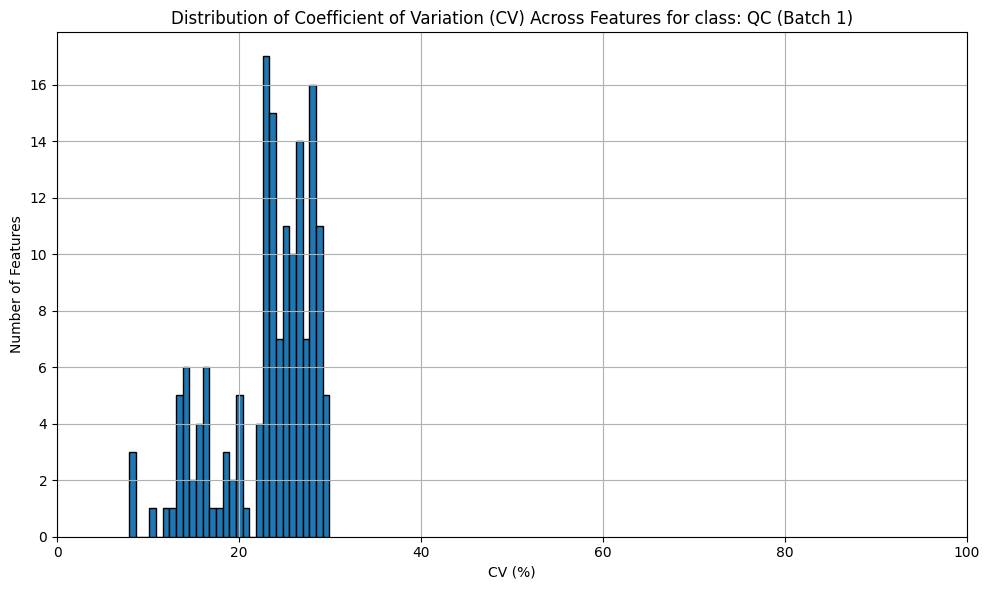

In [4]:
# Compute and Plot Coefficient of Variation (CV) of features across QC samples after filtering
cv_qc = cv(filtered_data_matrix, data_matrix_types, 'QC', 1, visualize=True, xlim=[0, 100])

## Feature Selection: consistent support in detection

Next, we will restrain our data to only keep features that are consistenly detected, i.e. the features that are detected more than 70% of the time across samples of the same class.
From the Exploratory Data Analysis, we have explored three ways to define a threshold for detection. Here, we will choose to work with the manual threshold.

In [5]:
threshold = 10 # manual threshold for peak area value to consider feature as detected
detected = 70 # only keep features that are detected >70% of the time

# Loop over classes of samples
classes = data_matrix_types['class']
reliable_features = []
for c in classes:
    # Only keep data of samples from specific class
    filtered_data_matrix_types = filtered_data_matrix.join(other=acquisition_list)
    class_data = filtered_data_matrix[filtered_data_matrix_types['class'] == c]
    
    # Keep only features detected in >=70% of samples
    detection_rate = (class_data > threshold).sum(axis=0)/len(class_data)*100 # compute percentage of samples where value > threshold
    
    for feature in detection_rate[detection_rate >= detected].index:
        if feature in reliable_features:
            break # don't add feature if it was already added before
        else:
            reliable_features.append(feature) # add feature to the reliable features

filtered_data_matrix = filtered_data_matrix[reliable_features]

# Print how many features were kept
print(f"Number of features left: {filtered_data_matrix.shape[1]}")

Number of features left: 159


## Feature Selection: within mass range of interest

In this part, we will only keep features that correspond to glycans, i.e. features for which mass-to-charge ratio (m/z) > 500.

In [6]:
# Identify features of m/z > 500
filtered_feature_metadata = feature_metadata.loc[filtered_data_matrix.columns]
glycan_features = filtered_feature_metadata[filtered_feature_metadata['mz'] > 500].index

# Filter data matrix to only keep features of m/z > 500
filtered_data_matrix = filtered_data_matrix[glycan_features]

# Print how many features were kept
print(f"Number of features left: {filtered_data_matrix.shape[1]}")

Number of features left: 156


## Feature Selection: variation of intensities

In this section, we will monitor the sample-to-sample intensity variations and check for possible transformations that could improve comparability.

### Intensity Distribution

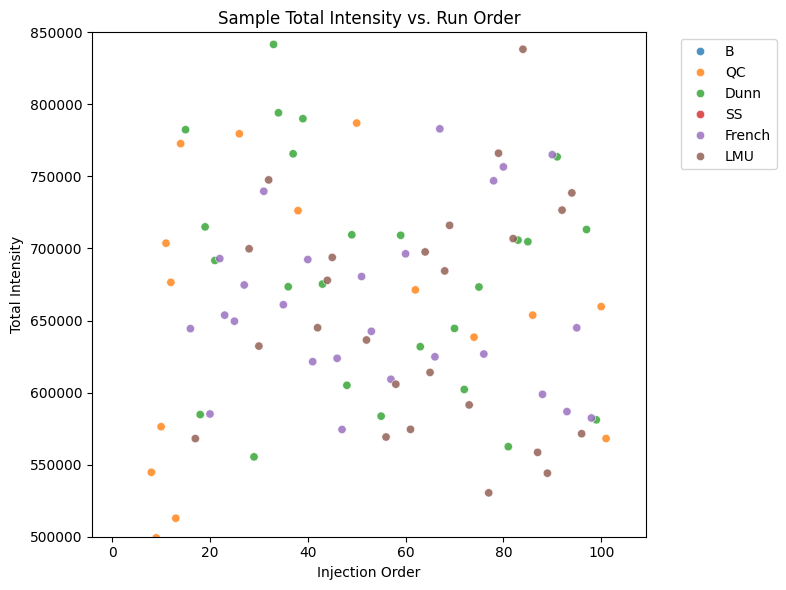

In [7]:
plot_total_intensity_vs_order(filtered_data_matrix, data_matrix_types, ylim=[500000, 850000])

- There's notable variation in total intensity across samples.
- We notice a slight downward drift, suggesting possible instrumental drift or sample degradation over time.

Since the intensity distributions suggest variability, we investigate normalization methods we can use to mitigate these effects. We then re-check intensity distributions to see whether they become more consistent.


### Normalization Methods

!! Not sure of doing this !! because creates weird results w.r.t. d-ratio

In [8]:
normalized_filtered_data_matrix = global_scaling_normalization(filtered_data_matrix)

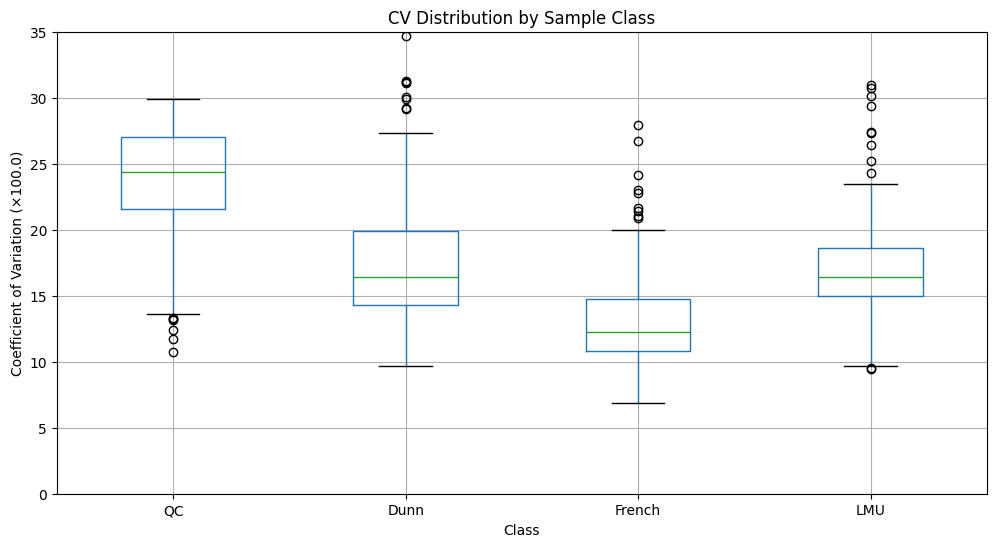

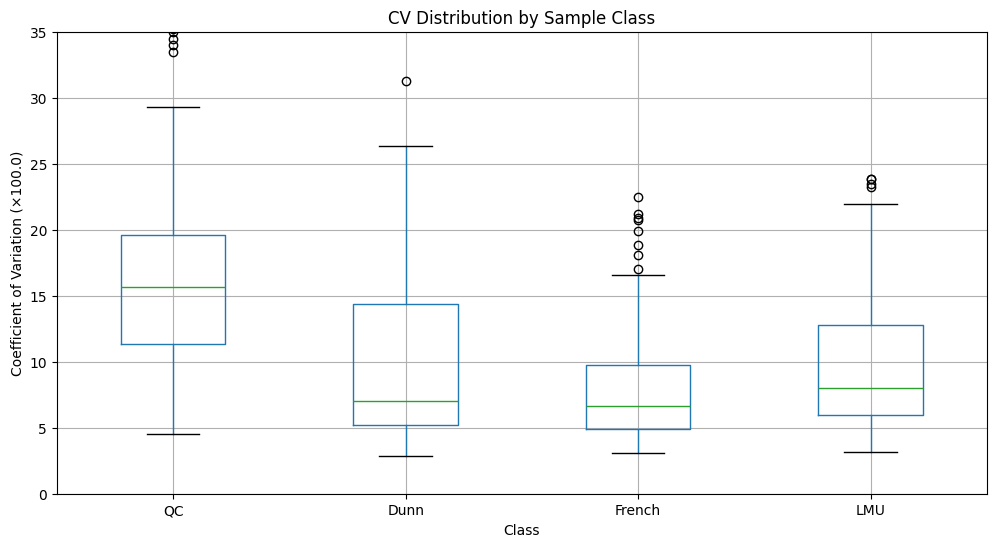

In [9]:
plot_cv_boxplots(filtered_data_matrix, data_matrix_types)
plot_cv_boxplots(normalized_filtered_data_matrix, data_matrix_types)

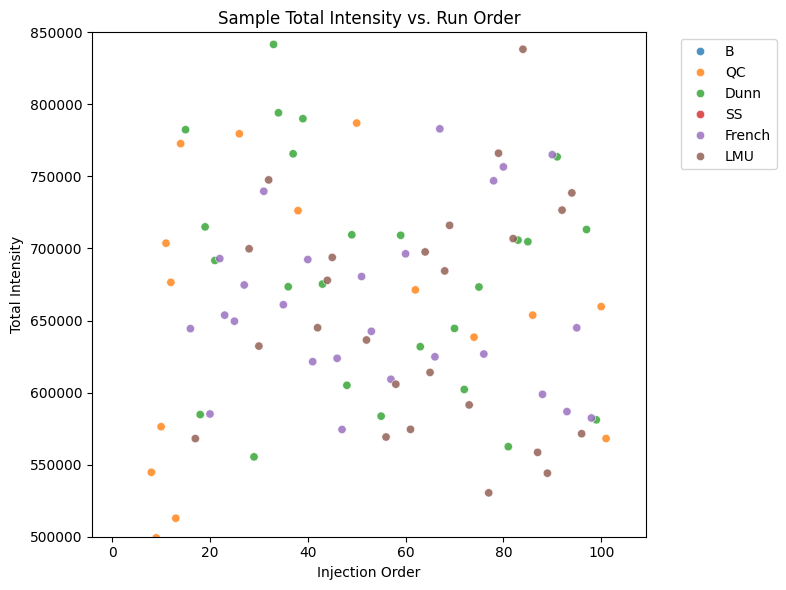

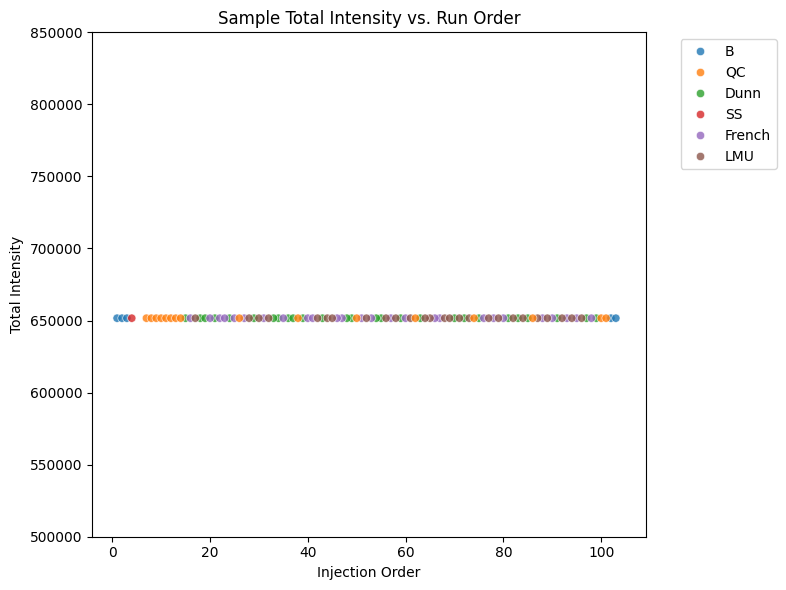

In [10]:
plot_total_intensity_vs_order(filtered_data_matrix, data_matrix_types, ylim=[500000, 850000])
plot_total_intensity_vs_order(normalized_filtered_data_matrix, data_matrix_types, ylim=[500000, 850000])

## Feature Selection: D-ratio

We remind the definition of the d-ratio:

The D-ratio represents the relation of the statistical dispersion of the QCs to the dispersion of the biological test samples. The D-ratio is calculated by dividing the technical variation by the total observed variation; this is the sum of technical and biological variation. Here, the variance of the QCs (𝜎2𝑖,𝑄⁢𝐶) approximates the technical variation, and the variance of the biological test samples (𝜎2𝑖,𝑠⁢𝑎⁢𝑚⁢𝑝⁢𝑙⁢𝑒) approximates the overall biological variation.

<img src="./images/D_ratio.png" alt="Alt Text" width="300"/>

A D-ratio close to 0% would be a perfect measurement, where the technical variance is zero and all observed variance originates from the biological variation. On the other hand, a D-ratio of 100% would be the worst possible measurement, where there is no biological variation and only noise is detected. A metabolite, where 𝜎2𝑖,𝑠⁢𝑎⁢𝑚⁢𝑝⁢𝑙⁢𝑒 ≫ 𝜎2𝑖,𝑄⁢𝐶 with a D-ratio below 50%, is preferred.

This information was provided in the paper [Instrumental Drift in Untargeted Metabolomics: Optimizing Data Correction Strategies](https://pmc.ncbi.nlm.nih.gov/articles/PMC10222478/).

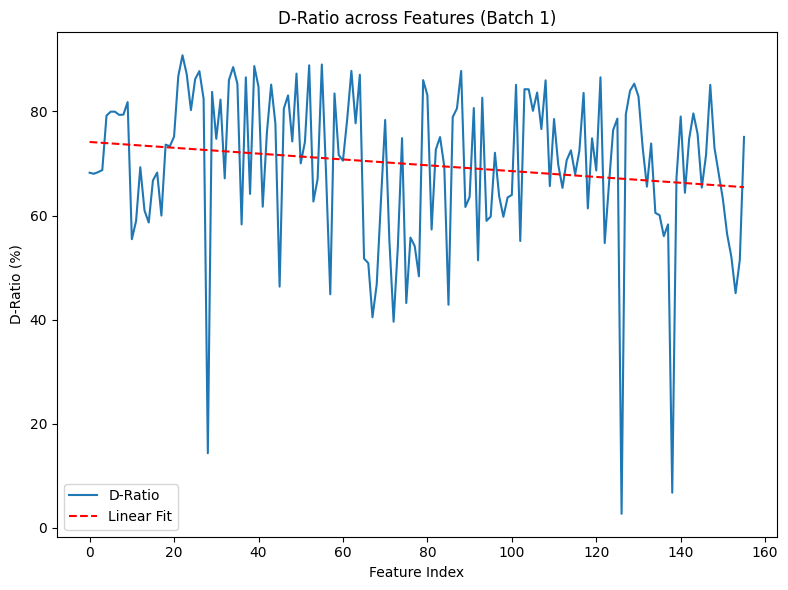

FT-002    68.225645
FT-004    68.029510
FT-005    68.341767
FT-006    68.743656
FT-007    79.202329
            ...    
FT-238    56.387579
FT-240    52.054736
FT-242    45.087069
FT-244    51.489760
FT-248    75.109081
Length: 156, dtype: float64

In [11]:
# Compute the d-ratio
compute_d_ratio(normalized_filtered_data_matrix, data_matrix_types, 1)

- D-Ratio values mostly range between 40–70%, with a few features dropping below 30% or even below 10%.
- A high D-Ratio (closer to 100%) indicates that most variability is technical, meaning the feature is less useful for distinguishing biological classes. Lower D-Ratio values (especially those under 50%) suggest stronger biological signal, i.e., the feature varies more between classes than within QC samples.
- The linear fit across all features shows a slight decreasing trend. This indicates no major drift in D-Ratio across the feature index.


Since the d-ratio values are relatively high, we investigate normalization methods to improve comparability between samples. We then re-check d-ratios to see if they decrease.

### Normalization methods

​Based on the normalization methods proposed in the paper [Instrumental Drift in Untargeted Metabolomics: Optimizing Data Correction Strategies](https://pmc.ncbi.nlm.nih.gov/articles/PMC10222478/), we can implement the following approaches to correct for batch effects and instrumental drift in our metabolomics dataset:​
- Median Normalization: This method normalizes each sample's metabolite signal by the median signal of the three chronologically closest QC samples. Using the median instead of the mean makes this approach more robust against outliers or missing values within the QCs.
- QC-Robust Spline Correction (QC-RSC): This method fits a smoothing spline to the QC samples for each metabolite across the injection order to model and correct for signal drift. Each sample is then normalized by the ratio of the median QC signal to the spline-predicted value at the sample's injection order.​
- TIGER algorithm: The TIGER algorithm is a more complex method that involves variable selection, model construction, and data correction steps. Implementing TIGER would require a more detailed understanding of its algorithmic steps and potentially additional information from the original publication.

/Users/aishamasmoudi/Desktop/ml-internship/helpers.py:86: UserWarning: Boolean Series key will be reindexed to match DataFrame index.
  numerator = data_matrix[(data_matrix_types['class'] == 'QC') & (data_matrix_types['batch'] == batch)].std()


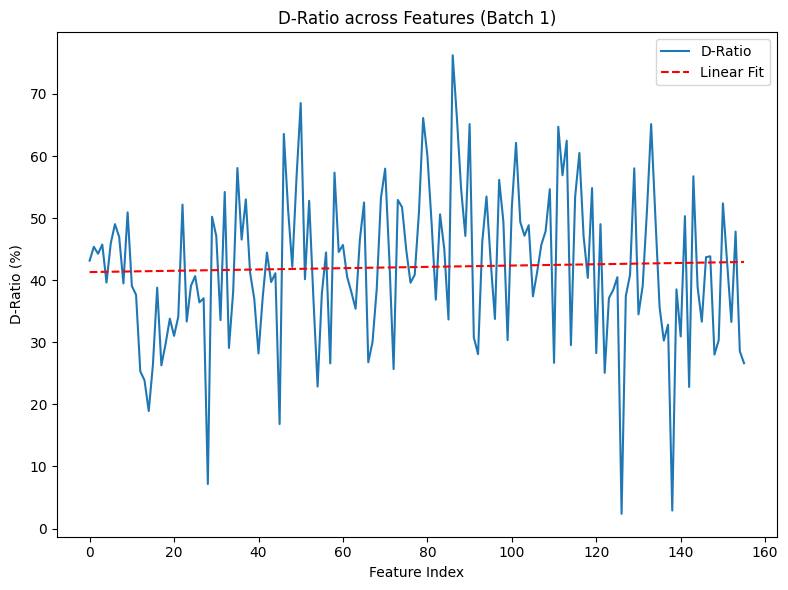

FT-002    43.148354
FT-004    45.377346
FT-005    44.260434
FT-006    45.741631
FT-007    39.620615
            ...    
FT-238    42.931385
FT-240    33.268440
FT-242    47.823398
FT-244    28.574565
FT-248    26.618858
Length: 156, dtype: float64

In [12]:
normalized_filtered_data_matrix = median_normalization(normalized_filtered_data_matrix, data_matrix_types, qc_class='QC')
compute_d_ratio(normalized_filtered_data_matrix, data_matrix_types, 1)

!! Also get rid of features with D-ratio > 50%